# Dexed dataset audit

Explore the Dexed dataset: link audio to preset parameters, extract descriptors, and build coverage maps of the behaviour space -- ending with the exact 38-feature space (6 ACTM + 32 TT) used by SpinVAE2's timbre loss.

## 1. Setup and paths

In [2]:
import os, sys, glob, re
os.environ['LD_LIBRARY_PATH'] = '/data/anasynth_nonbp/manaconda3/lib:' + os.environ.get('LD_LIBRARY_PATH','')

PROJECT_ROOT = os.path.expanduser('~/projects/spinvae2')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import soundfile as sf
import librosa
import librosa.display
import matplotlib.pyplot as plt
from IPython.display import Audio, display

DATASET_ROOT = '/data2/anasynth_nonbp/longeot/spinvae2_datasets/Dexed'
AUDIO_DIR = os.path.join(DATASET_ROOT, 'Audio')
PITCH, VEL = 56, 75

print('Audio dir exists:', os.path.isdir(AUDIO_DIR))
print('Nb wav files   :', len(glob.glob(os.path.join(AUDIO_DIR, '*.wav'))))

Audio dir exists: True
Nb wav files   : 120580


In [3]:
from synth.dexed import PresetDfDatabase
from synth.dexed import Dexed

db = PresetDfDatabase()
print('Nb presets in DB:', db.nb_presets)

def wav_path(uid, variation=0, pitch=PITCH, vel=VEL):
    stem = f"{uid:06d}_pitch{pitch:03d}vel{vel:03d}_var{variation:03d}.wav"
    return os.path.join(AUDIO_DIR, stem)

def uid_from_filename(fname):
    m = re.match(r"(\d{6})_", os.path.basename(fname))
    return int(m.group(1)) if m else None

all_uids = list(db.all_preset_UIDs)
print('Example UID:', all_uids[0], '->', wav_path(all_uids[0]))

Nb presets in DB: 30145
Example UID: 0 -> /data2/anasynth_nonbp/longeot/spinvae2_datasets/Dexed/Audio/000000_pitch056vel075_var000.wav


## 2. Explore a single preset

UID 0  |  BRITE RDS  (INCONI19)  |  var0


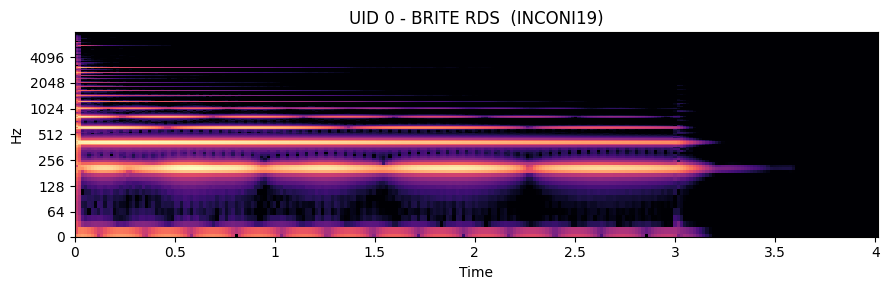

In [4]:
def explore_preset(uid, variation=0):
    name = db.get_preset_name(uid, long_name=True)
    path = wav_path(uid, variation)
    audio, sr = sf.read(path)
    if audio.ndim > 1:
        audio = audio.mean(axis=1)
    print(f"UID {uid}  |  {name}  |  var{variation}")
    S = librosa.amplitude_to_db(np.abs(librosa.stft(audio, n_fft=1024, hop_length=256)), ref=np.max)
    fig, ax = plt.subplots(figsize=(9,3))
    librosa.display.specshow(S, sr=sr, hop_length=256, x_axis='time', y_axis='log', ax=ax)
    ax.set_title(f"UID {uid} - {name}")
    plt.tight_layout(); plt.show()
    display(Audio(audio, rate=sr))

explore_preset(all_uids[0])

## 3. Lightweight librosa descriptors (first pass)

Generic audio features, computed quickly on a sample -- a first, rough look before using the perceptually-grounded 38-feature space (section 5).

In [5]:
def compute_librosa_descriptors(audio, sr):
    if audio.ndim > 1:
        audio = audio.mean(axis=1)
    if np.abs(audio).max() < 1e-6:
        return None
    feats = {}
    S = np.abs(librosa.stft(audio, n_fft=1024, hop_length=256))
    feats['centroid']  = float(np.mean(librosa.feature.spectral_centroid(S=S, sr=sr)))
    feats['bandwidth'] = float(np.mean(librosa.feature.spectral_bandwidth(S=S, sr=sr)))
    feats['rolloff']   = float(np.mean(librosa.feature.spectral_rolloff(S=S, sr=sr)))
    feats['flatness']  = float(np.mean(librosa.feature.spectral_flatness(S=S)))
    feats['rms']       = float(np.mean(librosa.feature.rms(S=S)))
    return feats

## 4. Perceptual descriptors: TimbreToolbox + AudioCommons

SpinVAE2's timbre loss uses **TimbreToolbox (TT)** and **AudioCommons Timbral Models (ACTM)** features, from
which an unsupervised correlation-based selection keeps 32 TT + 6 ACTM = **38 features** (`a in R^38` in the paper).

TT requires MATLAB (available on `bonsho`, not on `gottan`). The dataset's timbre features are computed via
`ds.compute_and_store_timbre_features()`, which writes `raw_timbre_features.df.pickle` -- loaded below.

In [6]:
import pathlib
from utils.timbrefeatures import TimbreFeatures, parse_timbre_features_arguments

raw_pickle = pathlib.Path(DATASET_ROOT) / 'raw_timbre_features.df.pickle'
raw_df = pd.read_pickle(raw_pickle)
print('Raw shape:', raw_df.shape)
print('Presets couverts:', raw_df['preset_UID'].nunique())

Raw shape: (241160, 97)
Presets couverts: 30145


In [7]:
# Apply the exact SpinVAE2 paper selection: log-scale + z-score normalisation (TimbreFeatures),
# then keep only the 38 features surviving the >0.9 correlation filter.
tf = TimbreFeatures(raw_pickle)
selected_38 = parse_timbre_features_arguments(['ac_*', 'tt_*', '__no_high_corr__'])
ac_38 = [f for f in selected_38 if f.startswith('ac_')]
tt_38 = [f for f in selected_38 if f.startswith('tt_')]
print(f'ACTM: {len(ac_38)} (papier: 6)')
print(f'TT: {len(tt_38)} (papier: 32)')

behaviour_df = tf.postproc_df[['preset_UID', 'variation'] + selected_38].copy()
behaviour_df = behaviour_df[behaviour_df['variation'] == 0].set_index('preset_UID')
print('Behaviour space (var0 only):', behaviour_df.shape)

ACTM: 6 (papier: 6)
TT: 32 (papier: 32)
Behaviour space (var0 only): (30145, 39)


## 5. Coverage map in the canonical 38-feature behaviour space

This is the actual behaviour space $Z$ used by SpinVAE2's timbre loss -- the map future IMGEP exploration will
be compared against.

Explained variance (2 PCs): 0.46047395754701315


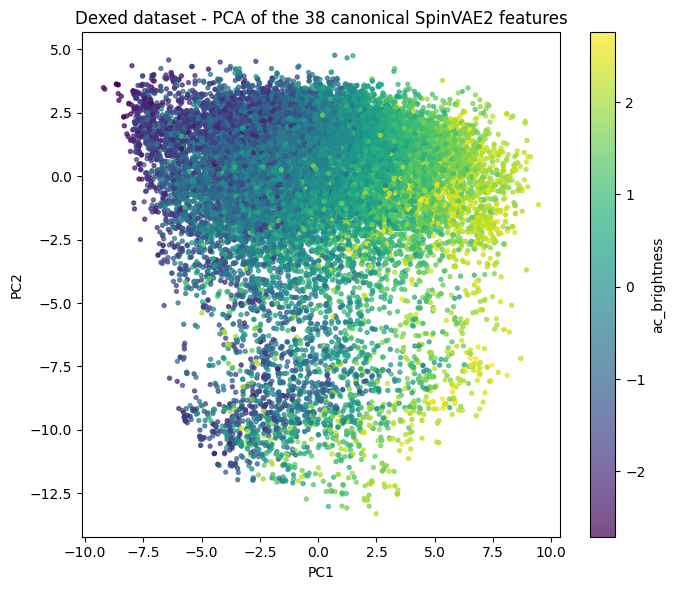

In [8]:
from sklearn.decomposition import PCA

X38 = np.nan_to_num(behaviour_df[selected_38].values)
pca38 = PCA(n_components=2)
X38p = pca38.fit_transform(X38)
print('Explained variance (2 PCs):', pca38.explained_variance_ratio_[:2].sum())

color_col = 'ac_brightness'
fig, ax = plt.subplots(figsize=(7,6))
sc = ax.scatter(X38p[:,0], X38p[:,1], c=behaviour_df[color_col], s=8, cmap='viridis', alpha=0.7)
plt.colorbar(sc, label=color_col)
ax.set_title('Dexed dataset - PCA of the 38 canonical SpinVAE2 features')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.tight_layout(); plt.show()

/data/anasynth_nonbp/longeot/envs/spinvae_2_18_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


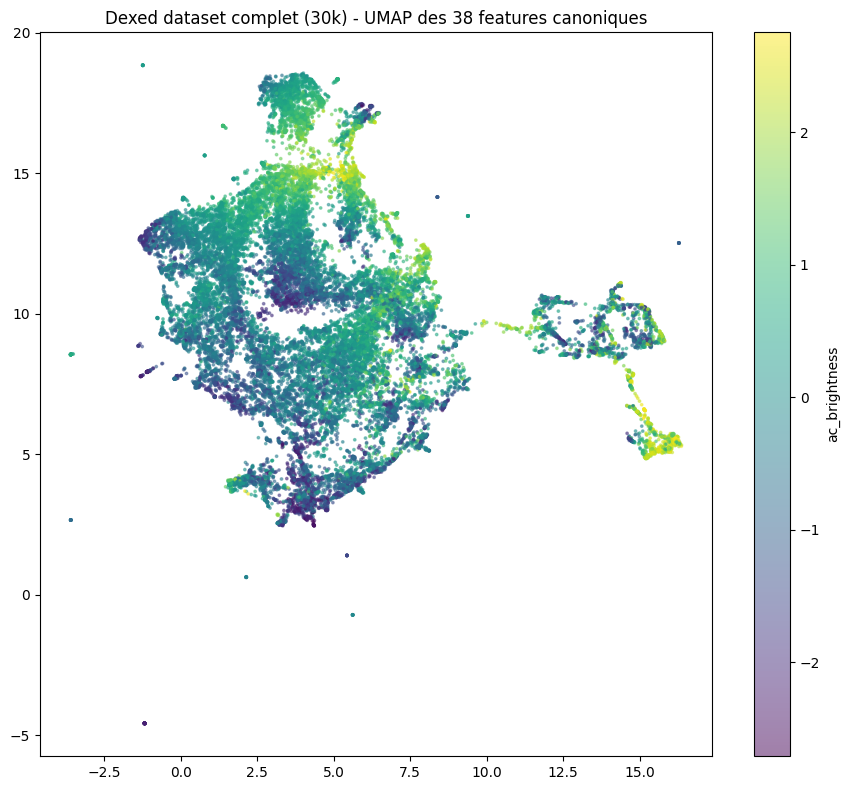

In [9]:
try:
    import sys
    sys.modules['umap.parametric_umap'] = None  # empêche l'import qui plante
    import umap
    reducer38 = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=0)
    reducer38 = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=0)
    X38u = reducer38.fit_transform(X38)

    fig, ax = plt.subplots(figsize=(9,8))
    sc = ax.scatter(X38u[:,0], X38u[:,1], c=behaviour_df['ac_brightness'], s=3, cmap='viridis', alpha=0.5)
    plt.colorbar(sc, label='ac_brightness')
    ax.set_title('Dexed dataset complet (30k) - UMAP des 38 features canoniques')
    plt.tight_layout(); plt.show()
    behaviour_df['umap_x'], behaviour_df['umap_y'] = X38u[:,0], X38u[:,1]
except ImportError:
    print('umap-learn not installed. Run: pip install umap-learn')
behaviour_df['pca_x'], behaviour_df['pca_y'] = X38p[:,0], X38p[:,1]

In [10]:
import plotly.graph_objects as go
from IPython.display import Audio, display, clear_output
import ipywidgets as widgets
import soundfile as sf

# Widget de sortie pour l'audio
audio_output = widgets.Output()

# Préparer les données pour Plotly
uids_list = list(behaviour_df.index)
names_list = [db.get_preset_name(uid) for uid in uids_list]

fig = go.FigureWidget(
    data=[go.Scatter(  # <-- Scatter au lieu de Scattergl
        x=X38u[:,0], y=X38u[:,1],
        mode='markers',
        marker=dict(size=4, color=behaviour_df['ac_brightness'], colorscale='Viridis', showscale=True),
        text=[f"UID {u}: {n}" for u, n in zip(uids_list, names_list)],
        hoverinfo='text'
    )],
    layout=go.Layout(width=800, height=700, title="Cliquer sur un point pour écouter le preset")
)

def on_click(trace, points, state):
    if points.point_inds:
        idx = points.point_inds[0]
        uid = uids_list[idx]
        name = names_list[idx]
        path = wav_path(uid, 0)
        with audio_output:
            clear_output(wait=True)
            print(f"UID {uid} - {name}")
            audio, sr = sf.read(path)
            display(Audio(audio, rate=sr))

fig.data[0].on_click(on_click)
display(fig)
display(audio_output)

FigureWidget({
    'data': [{'hoverinfo': 'text',
              'marker': {'color': {'bdata': ('Mx6qYf6X0L/kr8Bc2QzPP9oJ5m91XM' ... '5ux9D3v0Ua+JLgVd0/oAp5nHqe8z8='),
                                   'dtype': 'f8'},
                         'colorscale': [[0.0, '#440154'], [0.1111111111111111,
                                        '#482878'], [0.2222222222222222,
                                        '#3e4989'], [0.3333333333333333,
                                        '#31688e'], [0.4444444444444444,
                                        '#26828e'], [0.5555555555555556,
                                        '#1f9e89'], [0.6666666666666666,
                                        '#35b779'], [0.7777777777777778,
                                        '#6ece58'], [0.8888888888888888,
                                        '#b5de2b'], [1.0, '#fde725']],
                         'showscale': True,
                         'size': 4},
              'mode': 'markers',
       

Output()

In [18]:
import re
from collections import Counter

# Récupérer tous les noms de presets (variation 0 uniquement, cohérent avec behaviour_df)
names_all = {uid: db.get_preset_name(uid, long_name=False).upper() for uid in behaviour_df.index}

# Regarder les mots les plus fréquents pour repérer les catégories naturelles
word_counter = Counter()
for name in names_all.values():
    words = re.findall(r'[A-Z]+', name)
    word_counter.update(words)

print("Mots les plus fréquents dans les noms de presets :")
for word, count in word_counter.most_common(40):
    print(f"  {word:15s} {count}")

Mots les plus fréquents dans les noms de presets :
  PIANO           1058
  BASS            1053
  E               824
  B               739
  A               716
  BRASS           542
  Y               463
  SYN             451
  STRINGS         377
  CLAV            334
  ORGAN           303
  S               278
  SYNTH           267
  BELL            260
  BS              247
  RHODES          238
  STRING          238
  PNO             229
  FLUTE           222
  LEAD            220
  HORN            208
  STR             205
  X               196
  BC              187
  DX              186
  M               176
  P               167
  F               167
  PAD             159
  HARP            159
  VOICE           158
  GUITAR          150
  PERC            147
  BRS             142
  C               139
  T               138
  D               135
  STRG            134
  ORG             129
  SOLO            128


In [19]:
categories = {
    'PIANO':   ['PIANO', 'PNO'],
    'BASS':    ['BASS', 'BS'],
    'BRASS':   ['BRASS', 'BRS', 'HORN'],
    'STRINGS': ['STRINGS', 'STRING', 'STR', 'STRG'],
    'ORGAN':   ['ORGAN', 'ORG'],
    'BELL':    ['BELL', 'CHIME'],
    'SYNTH':   ['SYN', 'SYNTH'],
    'LEAD':    ['LEAD'],
    'PAD':     ['PAD'],
    'FLUTE':   ['FLUTE'],
    'CLAV':    ['CLAV'],
    'RHODES':  ['RHODES'],
    'PERC':    ['PERC'],
    'GUITAR':  ['GUITAR'],
    'VOICE':   ['VOICE'],
    'HARP':    ['HARP'],
}

def categorize(name):
    for cat, keywords in categories.items():
        if any(kw in name for kw in keywords):
            return cat
    return 'OTHER'

names_all = {uid: db.get_preset_name(uid, long_name=False).upper() for uid in behaviour_df.index}
cat_labels = pd.Series({uid: categorize(names_all[uid]) for uid in behaviour_df.index}, name='category')

print(cat_labels.value_counts())

OTHER      17206
BASS        2124
PIANO       1954
STRINGS     1763
BRASS       1518
SYNTH       1496
ORGAN        816
BELL         701
CLAV         499
FLUTE        340
HARP         338
VOICE        318
RHODES       305
GUITAR       224
LEAD         201
PAD          196
PERC         146
Name: category, dtype: int64


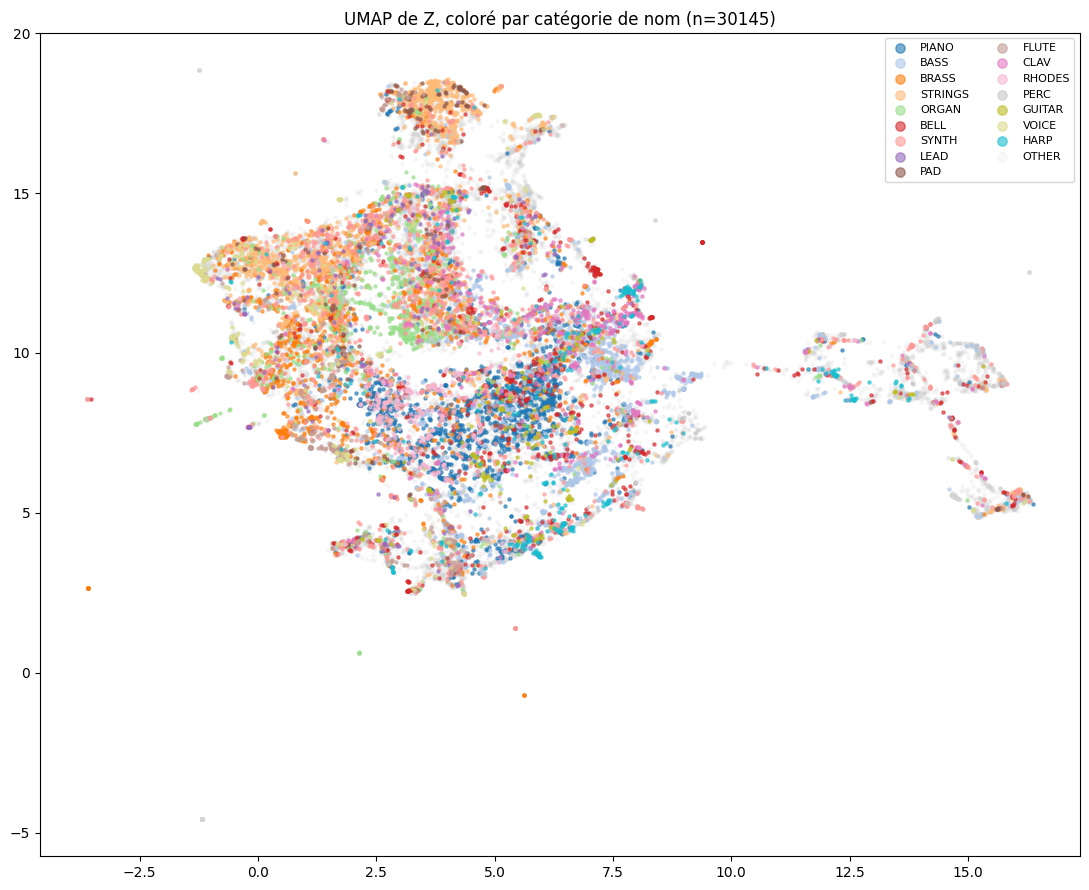

In [20]:
fig, ax = plt.subplots(figsize=(11,9))
palette = plt.cm.tab20(np.linspace(0, 1, len(categories)+1))
for i, cat in enumerate(list(categories.keys()) + ['OTHER']):
    mask = (cat_labels.reindex(behaviour_df.index) == cat).values
    color = 'lightgray' if cat == 'OTHER' else palette[i]
    zorder = 1 if cat == 'OTHER' else 2
    alpha = 0.15 if cat == 'OTHER' else 0.6
    ax.scatter(X38u[mask,0], X38u[mask,1], s=5, alpha=alpha, color=color, label=cat, zorder=zorder)
ax.legend(markerscale=3, loc='best', fontsize=8, ncol=2)
ax.set_title(f'UMAP de Z, coloré par catégorie de nom (n={len(behaviour_df)})')
plt.tight_layout(); plt.show()

In [ ]:
import plotly.graph_objects as go
from IPython.display import Audio, display, clear_output
import ipywidgets as widgets
import soundfile as sf
import matplotlib.colors as mcolors

audio_output = widgets.Output()

uids_list = list(behaviour_df.index)
names_list = [db.get_preset_name(uid) for uid in uids_list]
cat_array = cat_labels.reindex(behaviour_df.index).values

qualitative_colors = list(mcolors.TABLEAU_COLORS.values()) + list(plt.cm.Set1(np.linspace(0,1,9)))
all_cats_ordered = list(categories.keys()) + ['OTHER']
palette = [mcolors.to_rgba(c) if isinstance(c, str) else c for c in qualitative_colors][:len(categories)]
palette.append((0.83, 0.83, 0.83, 1.0))

def rgb_hex(rgba):
    return '#{:02x}{:02x}{:02x}'.format(int(rgba[0]*255), int(rgba[1]*255), int(rgba[2]*255))

fig = go.FigureWidget(layout=go.Layout(width=1000, height=800, title="Cliquer sur un point pour écouter le preset"))

trace_to_uids = {}  # clé = id(trace), valeur = liste d'UIDs

for i, cat in enumerate(all_cats_ordered):
    mask = cat_array == cat
    idx_in_cat = np.where(mask)[0]
    color = rgb_hex(palette[i])
    size = 3 if cat == 'OTHER' else 5
    opacity = 0.15 if cat == 'OTHER' else 0.85

    fig.add_trace(go.Scatter(
        x=X38u[mask,0], y=X38u[mask,1],
        mode='markers',
        marker=dict(size=size, color=color, opacity=opacity),
        name=cat,
        text=[f"UID {uids_list[j]}: {names_list[j]}" for j in idx_in_cat],
        hoverinfo='text',
        showlegend=False,
        legendgroup=cat,
    ))
    trace_to_uids[id(fig.data[-1])] = [uids_list[j] for j in idx_in_cat]

    fig.add_trace(go.Scatter(
        x=[None], y=[None],
        mode='markers',
        marker=dict(size=16, color=color),
        name=cat,
        legendgroup=cat,
        showlegend=True,
        hoverinfo='skip',
    ))

def on_click(trace, points, state):
    key = id(trace)
    if points.point_inds and key in trace_to_uids:
        local_idx = points.point_inds[0]
        uid = trace_to_uids[key][local_idx]
        name = db.get_preset_name(uid)
        path = wav_path(uid, 0)
        with audio_output:
            clear_output(wait=True)
            print(f"UID {uid} - {name}")
            audio, sr = sf.read(path)
            display(Audio(audio, rate=sr))

for trace in fig.data:
    if id(trace) in trace_to_uids:
        trace.on_click(on_click)

display(fig)
display(audio_output)

FigureWidget({
    'data': [{'hoverinfo': 'text',
              'legendgroup': 'PIANO',
              'marker': {'color': '#1f77b4', 'opacity': 0.85, 'size': 5},
              'mode': 'markers',
              'name': 'PIANO',
              'showlegend': False,
              'text': [UID 12: BRT.EL.PNO, UID 71: Chorus PNO, UID 216:
                       SPELECPNO1, ..., UID 390260: PIANO 4DDL, UID 393764:
                       PianoBrite, UID 393856: CrashPiano],
              'type': 'scatter',
              'uid': '2a1509df-3d1b-47df-b901-03ba690402cb',
              'x': {'bdata': ('XQmjQGnQgUDIYiVAqVw/QamQqkBNR6' ... 'AYTnhA3KS+QKCZxUAZxDJAkUQuQA=='),
                    'dtype': 'f4'},
              'y': {'bdata': ('MWqDQM5OF0GmPBFB5m4mQTy1A0G04S' ... 'FxXcJAx4/uQB7qEUEskRJBYTf4QA=='),
                    'dtype': 'f4'}},
             {'hoverinfo': 'skip',
              'legendgroup': 'PIANO',
              'marker': {'color': '#1f77b4', 'size': 16},
              'mode': 'marker

Output()

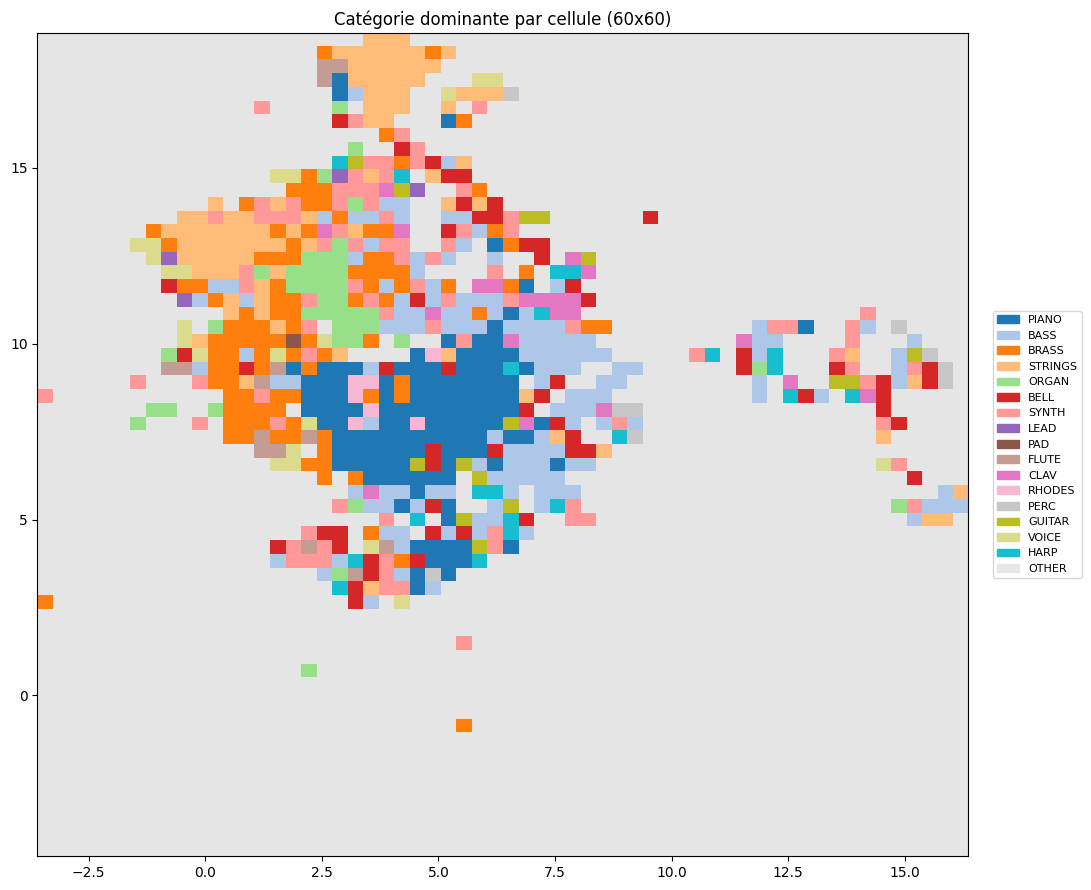

In [23]:
from scipy.stats import mode

n_bins = 60  # grille plus fine (60x60 au lieu de 30x30)
x_edges = np.linspace(X38u[:,0].min(), X38u[:,0].max(), n_bins+1)
y_edges = np.linspace(X38u[:,1].min(), X38u[:,1].max(), n_bins+1)

grid_cat = np.full((n_bins, n_bins), 'OTHER', dtype=object)
cat_array = cat_labels.reindex(behaviour_df.index).values

for i in range(n_bins):
    for j in range(n_bins):
        in_cell = (X38u[:,0] >= x_edges[i]) & (X38u[:,0] < x_edges[i+1]) & \
                  (X38u[:,1] >= y_edges[j]) & (X38u[:,1] < y_edges[j+1])
        cats_in_cell = cat_array[in_cell]
        cats_in_cell = cats_in_cell[cats_in_cell != 'OTHER']
        if len(cats_in_cell) >= 2:  # seuil abaissé, grille plus fine = moins de points par cellule
            vals, counts = np.unique(cats_in_cell, return_counts=True)
            grid_cat[i, j] = vals[np.argmax(counts)]

all_cats_ordered = list(categories.keys()) + ['OTHER']
cat_to_int = {c: i for i, c in enumerate(all_cats_ordered)}
grid_int = np.vectorize(cat_to_int.get)(grid_cat)

# Colormap discrète avec une couleur par catégorie
from matplotlib.colors import ListedColormap, BoundaryNorm
cmap_colors = plt.cm.tab20(np.linspace(0, 1, len(all_cats_ordered)))
cmap_colors[all_cats_ordered.index('OTHER')] = [0.9, 0.9, 0.9, 1.0]  # gris clair pour OTHER
cmap = ListedColormap(cmap_colors)
norm = BoundaryNorm(np.arange(len(all_cats_ordered)+1)-0.5, cmap.N)

fig, ax = plt.subplots(figsize=(11,9))
im = ax.imshow(grid_int.T, origin='lower', cmap=cmap, norm=norm,
               extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]], aspect='auto')
ax.set_title(f'Catégorie dominante par cellule ({n_bins}x{n_bins})')

# Légende avec patches colorés
import matplotlib.patches as mpatches
patches = [mpatches.Patch(color=cmap_colors[i], label=cat) for i, cat in enumerate(all_cats_ordered)]
ax.legend(handles=patches, loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)

plt.tight_layout(); plt.show()

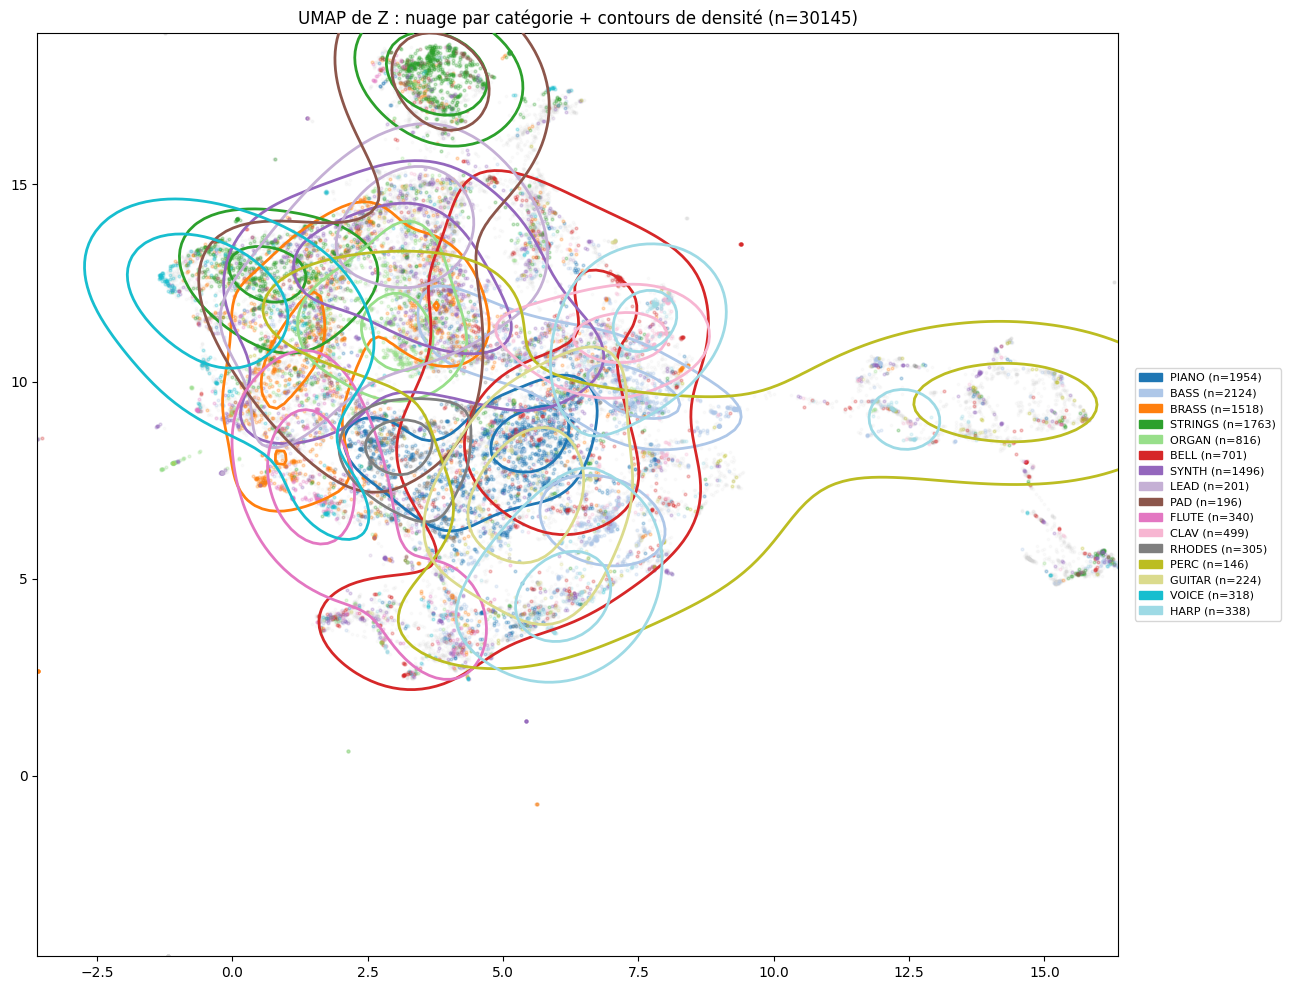

In [25]:
from scipy.stats import gaussian_kde
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(13,10))

all_cats_ordered = list(categories.keys())
palette = plt.cm.tab20(np.linspace(0, 1, len(all_cats_ordered)))
cat_array = cat_labels.reindex(behaviour_df.index).values

# 1. Scatter de fond : tous les points, OTHER en gris clair, catégories nommées en couleur légère
mask_other = cat_array == 'OTHER'
ax.scatter(X38u[mask_other,0], X38u[mask_other,1], s=3, alpha=0.08, color='lightgray', zorder=1)
for i, cat in enumerate(all_cats_ordered):
    mask = cat_array == cat
    ax.scatter(X38u[mask,0], X38u[mask,1], s=4, alpha=0.25, color=palette[i], zorder=2)

# 2. Contours de densité par-dessus, uniquement pour les catégories assez peuplées
xmin, xmax = X38u[:,0].min(), X38u[:,0].max()
ymin, ymax = X38u[:,1].min(), X38u[:,1].max()
xx, yy = np.mgrid[xmin:xmax:150j, ymin:ymax:150j]

legend_patches = []
for i, cat in enumerate(all_cats_ordered):
    mask = cat_array == cat
    if mask.sum() < 30:
        continue
    pts = X38u[mask]
    try:
        kde = gaussian_kde(pts.T)
        zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
        ax.contour(xx, yy, zz, levels=2, colors=[palette[i]], linewidths=2, zorder=3)
        legend_patches.append(mpatches.Patch(color=palette[i], label=f"{cat} (n={mask.sum()})"))
    except Exception:
        pass

ax.legend(handles=legend_patches, loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=8)
ax.set_title(f'UMAP de Z : nuage par catégorie + contours de densité (n={len(behaviour_df)})')
plt.tight_layout(); plt.show()

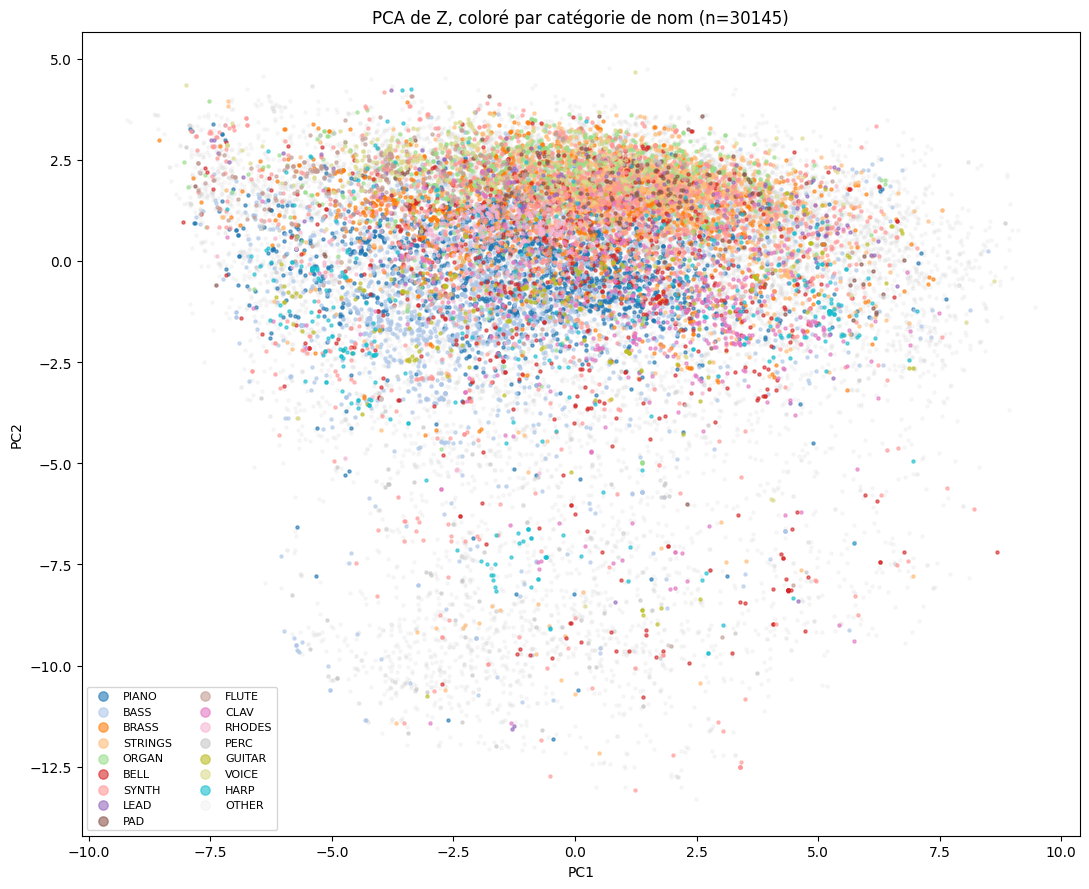

In [21]:
fig, ax = plt.subplots(figsize=(11,9))
palette = plt.cm.tab20(np.linspace(0, 1, len(categories)+1))
for i, cat in enumerate(list(categories.keys()) + ['OTHER']):
    mask = (cat_labels.reindex(behaviour_df.index) == cat).values
    color = 'lightgray' if cat == 'OTHER' else palette[i]
    zorder = 1 if cat == 'OTHER' else 2
    alpha = 0.15 if cat == 'OTHER' else 0.6
    ax.scatter(X38p[mask,0], X38p[mask,1], s=5, alpha=alpha, color=color, label=cat, zorder=zorder)
ax.legend(markerscale=3, loc='best', fontsize=8, ncol=2)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title(f'PCA de Z, coloré par catégorie de nom (n={len(behaviour_df)})')
plt.tight_layout(); plt.show()

### 5bis. Same map, coloured by a spectral (TT) feature

`ac_brightness` is a semantic/perceptual descriptor. Colouring by a raw spectral TT feature
(`tt_SpecCent_IQR`, the interquartile range of spectral centroid over time -- a proxy for
how much the timbre's brightness varies within a single note) checks whether the map's
structure is specific to one descriptor or reflects a more general organisation.

/data/anasynth_nonbp/longeot/envs/spinvae_2_18_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


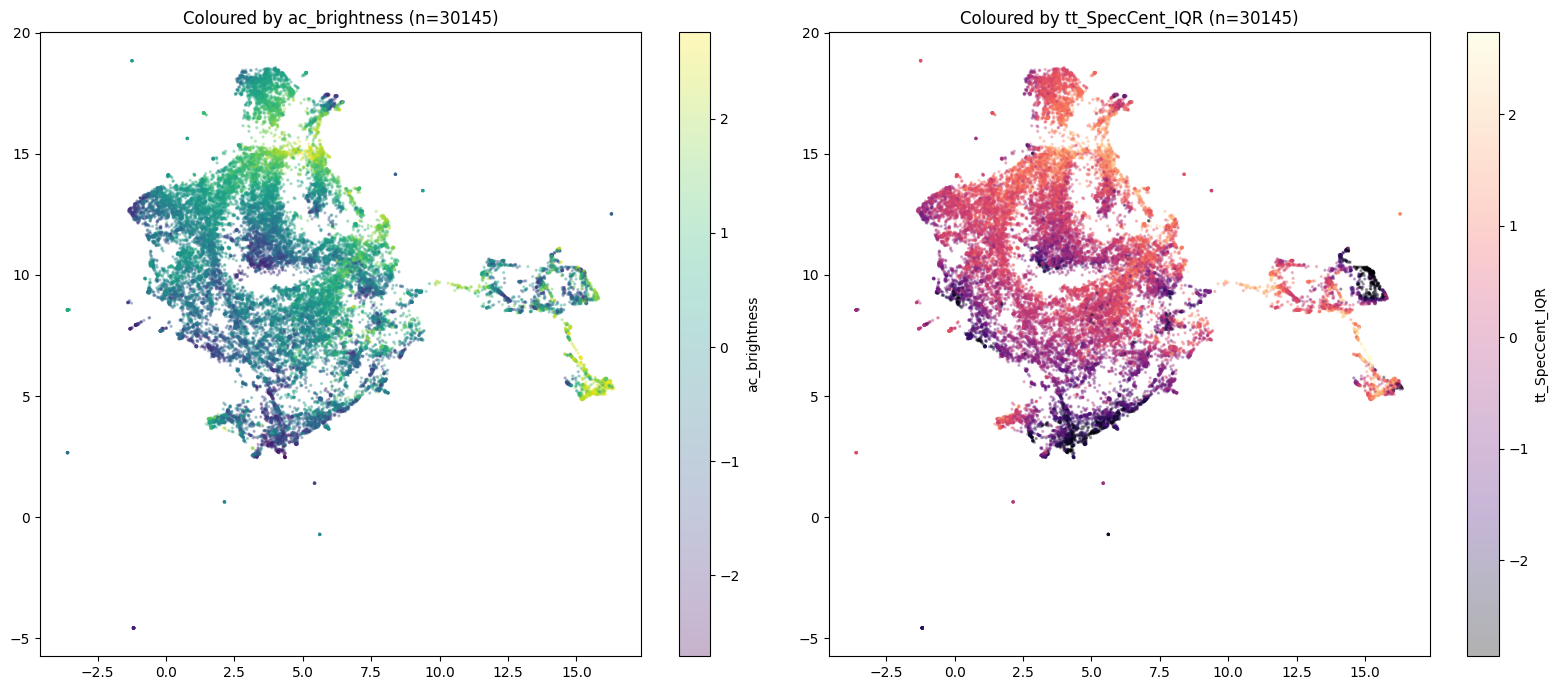

In [11]:
reducer38b = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=0)
X38u_b = reducer38b.fit_transform(X38)  # same embedding params, kept separate for clarity

fig, axes = plt.subplots(1, 2, figsize=(16,7))
sc0 = axes[0].scatter(X38u_b[:,0], X38u_b[:,1], c=behaviour_df['ac_brightness'], s=2, cmap='viridis', alpha=0.3)
plt.colorbar(sc0, ax=axes[0], label='ac_brightness')
axes[0].set_title(f'Coloured by ac_brightness (n={len(X38u_b)})')

sc1 = axes[1].scatter(X38u_b[:,0], X38u_b[:,1], c=behaviour_df['tt_SpecCent_IQR'], s=2, cmap='magma', alpha=0.3)
plt.colorbar(sc1, ax=axes[1], label='tt_SpecCent_IQR')
axes[1].set_title(f'Coloured by tt_SpecCent_IQR (n={len(X38u_b)})')
plt.tight_layout(); plt.show()

### 5ter. Quantifying coverage

Two simple, standard Quality-Diversity coverage metrics, computed on the UMAP embedding:
- **Grid occupancy**: divide the 2D map into an N x N grid, count occupied cells / total cells.
- **Mean nearest-neighbour distance**: average distance from each point to its closest neighbour
  -- higher values indicate sparser, more uneven coverage.

These give a numeric baseline to compare against once IMGEP-guided exploration is available.

In [12]:
from scipy.spatial import cKDTree

def grid_occupancy(points, n_bins=20):
    x, y = points[:,0], points[:,1]
    x_edges = np.linspace(x.min(), x.max(), n_bins+1)
    y_edges = np.linspace(y.min(), y.max(), n_bins+1)
    H, _, _ = np.histogram2d(x, y, bins=[x_edges, y_edges])
    occupied = (H > 0).sum()
    total = n_bins * n_bins
    return occupied / total, occupied, total

def mean_nn_distance(points):
    tree = cKDTree(points)
    dists, _ = tree.query(points, k=2)  # k=1 is itself (dist 0), k=2 is the true nearest neighbour
    return float(np.mean(dists[:,1]))

occ_ratio, occ_cells, total_cells = grid_occupancy(X38u, n_bins=50)
nn_dist = mean_nn_distance(X38u)
print(f"Grid occupancy (50x50): {occ_cells}/{total_cells} cells = {100*occ_ratio:.1f}%")
print(f"Mean nearest-neighbour distance: {nn_dist:.4f}")
print(f"(sur {len(X38u)} presets)")

Grid occupancy (50x50): 671/2500 cells = 26.8%
Mean nearest-neighbour distance: 0.0228
(sur 30145 presets)


## 5quater. Coverage map in the raw parameter space (Θ)

Same PCA/UMAP/coverage analysis, but performed directly on the 155 raw Dexed parameters
instead of the 38-feature behaviour space. This checks whether human-made presets cover
the parameter space Θ as unevenly as they cover the perceptual behaviour space Z, and
whether the two spaces show a similar or markedly different structure -- which would
be informative about the non-linearity of the Θ→Z mapping that SpinVAE2 itself is
built to learn.

In [13]:
# Récupérer les paramètres bruts pour tous les presets (variation 0 = presets originaux)
from synth.dexed import PresetDfDatabase
db = PresetDfDatabase()

all_uids_ordered = list(behaviour_df.index)  # même ordre que le comportement, pour comparer
params_matrix = np.array([db.get_preset_params_values(uid) for uid in all_uids_ordered])
print("Shape params bruts:", params_matrix.shape)  # attendu: (30145, 155)

Shape params bruts: (30145, 155)


Explained variance Theta (2 PCs): 0.17467707


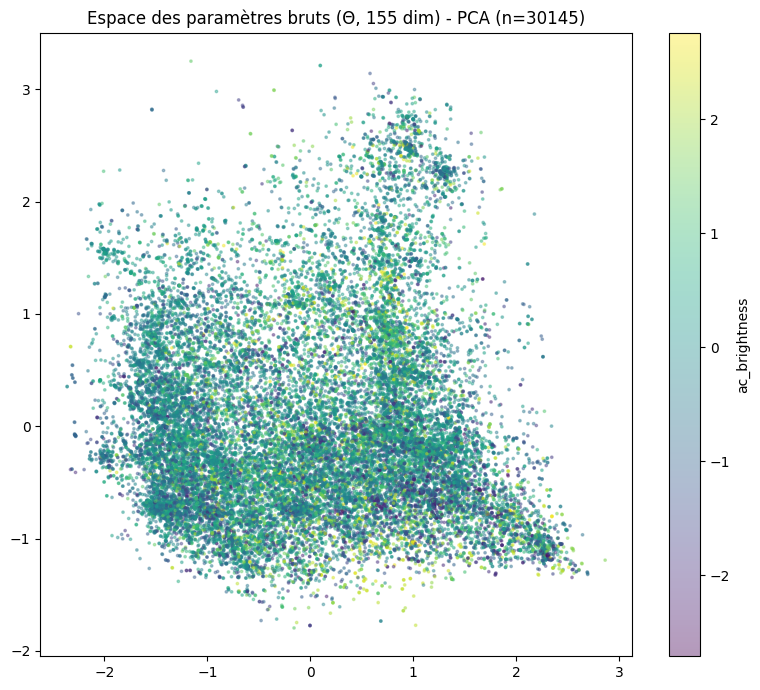

In [14]:
pca_theta = PCA(n_components=2)
Xtheta_p = pca_theta.fit_transform(params_matrix)
print('Explained variance Theta (2 PCs):', pca_theta.explained_variance_ratio_[:2].sum())

fig, ax = plt.subplots(figsize=(8,7))
sc = ax.scatter(Xtheta_p[:,0], Xtheta_p[:,1], c=behaviour_df['ac_brightness'], s=3, cmap='viridis', alpha=0.4)
plt.colorbar(sc, label='ac_brightness')
ax.set_title(f'Espace des paramètres bruts (Θ, 155 dim) - PCA (n={len(params_matrix)})')
plt.tight_layout(); plt.show()

/data/anasynth_nonbp/longeot/envs/spinvae_2_18_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


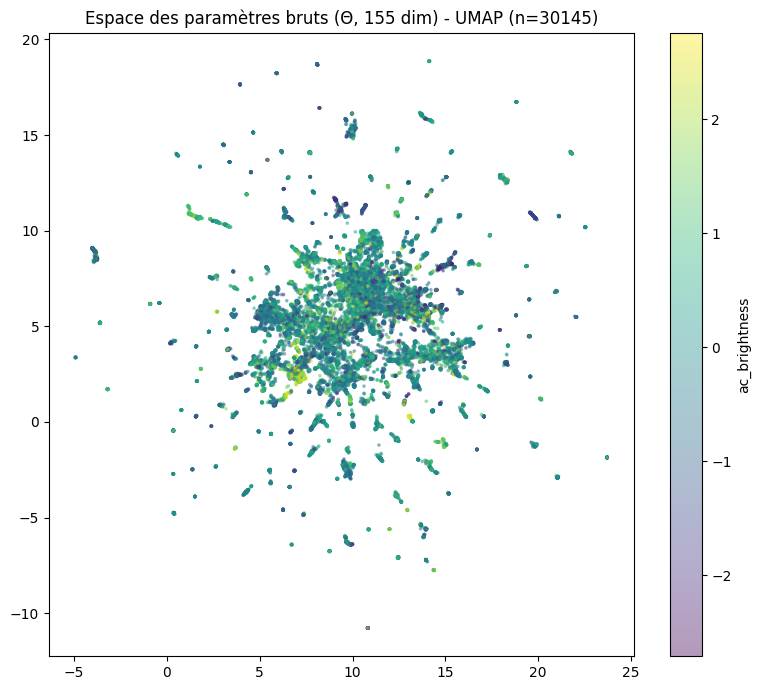

In [15]:
reducer_theta = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=0)
Xtheta_u = reducer_theta.fit_transform(params_matrix)

fig, ax = plt.subplots(figsize=(8,7))
sc = ax.scatter(Xtheta_u[:,0], Xtheta_u[:,1], c=behaviour_df['ac_brightness'], s=3, cmap='viridis', alpha=0.4)
plt.colorbar(sc, label='ac_brightness')
ax.set_title(f'Espace des paramètres bruts (Θ, 155 dim) - UMAP (n={len(params_matrix)})')
plt.tight_layout(); plt.show()

In [16]:
occ_ratio_theta, occ_cells_theta, total_cells_theta = grid_occupancy(Xtheta_u, n_bins=50)
nn_dist_theta = mean_nn_distance(Xtheta_u)
print(f"Grid occupancy Theta (50x50): {occ_cells_theta}/{total_cells_theta} = {100*occ_ratio_theta:.1f}%")
print(f"Mean NN distance Theta: {nn_dist_theta:.4f}")

Grid occupancy Theta (50x50): 513/2500 = 20.5%
Mean NN distance Theta: 0.0141


## Native 38D coverage metrics and alternative projections

Coverage metrics computed on 2D embeddings (PCA, UMAP) are limited by the fact that these
projections are not isometries -- distances and neighbourhoods can be distorted. Here we
compute nearest-neighbour-based coverage metrics directly in the native 38-dimensional
behaviour space, and compare against a uniform-random baseline of the same size and bounding
box. We also compare UMAP against t-SNE and Isomap as alternative 2D projections.

In [26]:
from scipy.spatial import cKDTree

def mean_nn_distance_nd(X):
    tree = cKDTree(X)
    dists, _ = tree.query(X, k=2)
    return float(np.mean(dists[:,1]))

def mean_knn_distance_nd(X, k=5):
    tree = cKDTree(X)
    dists, _ = tree.query(X, k=k+1)
    return float(np.mean(dists[:,1:]))

nn_dist_38d = mean_nn_distance_nd(X38)
knn5_38d = mean_knn_distance_nd(X38, k=5)
print(f"Mean NN distance (native 38D): {nn_dist_38d:.4f}")
print(f"Mean 5-NN distance (native 38D): {knn5_38d:.4f}")

# Baseline: uniform random sample, same size and bounding box
np.random.seed(0)
X_uniform_random = np.random.uniform(X38.min(axis=0), X38.max(axis=0), size=X38.shape)
nn_dist_random = mean_nn_distance_nd(X_uniform_random)
knn5_random = mean_knn_distance_nd(X_uniform_random, k=5)

print(f"\nMean NN distance (uniform random baseline): {nn_dist_random:.4f}")
print(f"Mean 5-NN distance (uniform random baseline): {knn5_random:.4f}")

print(f"\nRatio NN (dataset / uniform random): {nn_dist_38d / nn_dist_random:.3f}")
print(f"Ratio 5-NN (dataset / uniform random): {knn5_38d / knn5_random:.3f}")

Mean NN distance (native 38D): 1.1234
Mean 5-NN distance (native 38D): 1.8008

Mean NN distance (uniform random baseline): 9.7055
Mean 5-NN distance (uniform random baseline): 10.2104

Ratio NN (dataset / uniform random): 0.116
Ratio 5-NN (dataset / uniform random): 0.176


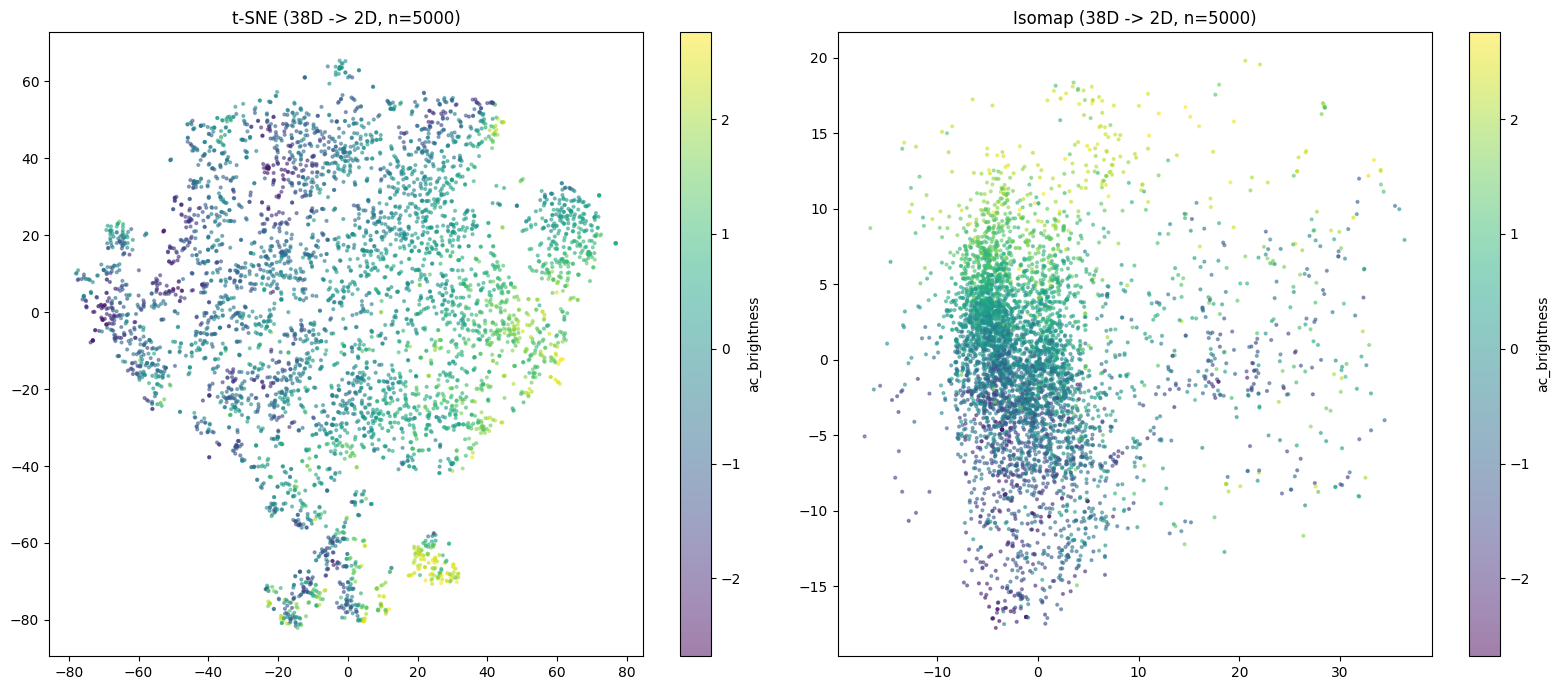

In [ ]:
from sklearn.manifold import TSNE, Isomap

# Sous-échantillon pour garder ça rapide (t-SNE/Isomap sont coûteux sur 30k points)
n_sub = 5000
np.random.seed(0)
sub_idx = np.random.choice(len(X38), size=n_sub, replace=False)
X38_sub = X38[sub_idx]
brightness_sub = behaviour_df['ac_brightness'].values[sub_idx]

tsne = TSNE(n_components=2, perplexity=30, random_state=0)
X38_tsne = tsne.fit_transform(X38_sub)

isomap = Isomap(n_components=2, n_neighbors=15)
X38_isomap = isomap.fit_transform(X38_sub)

fig, axes = plt.subplots(1, 2, figsize=(16,7))
sc0 = axes[0].scatter(X38_tsne[:,0], X38_tsne[:,1], c=brightness_sub, s=4, cmap='viridis', alpha=0.5)
axes[0].set_title(f't-SNE (38D -> 2D, n={n_sub})')
plt.colorbar(sc0, ax=axes[0], label='ac_brightness')

sc1 = axes[1].scatter(X38_isomap[:,0], X38_isomap[:,1], c=brightness_sub, s=4, cmap='viridis', alpha=0.5)
axes[1].set_title(f'Isomap (38D -> 2D, n={n_sub})')
plt.colorbar(sc1, ax=axes[1], label='ac_brightness')
plt.tight_layout(); plt.show()

t-SNE (30k) termine en 312.2s


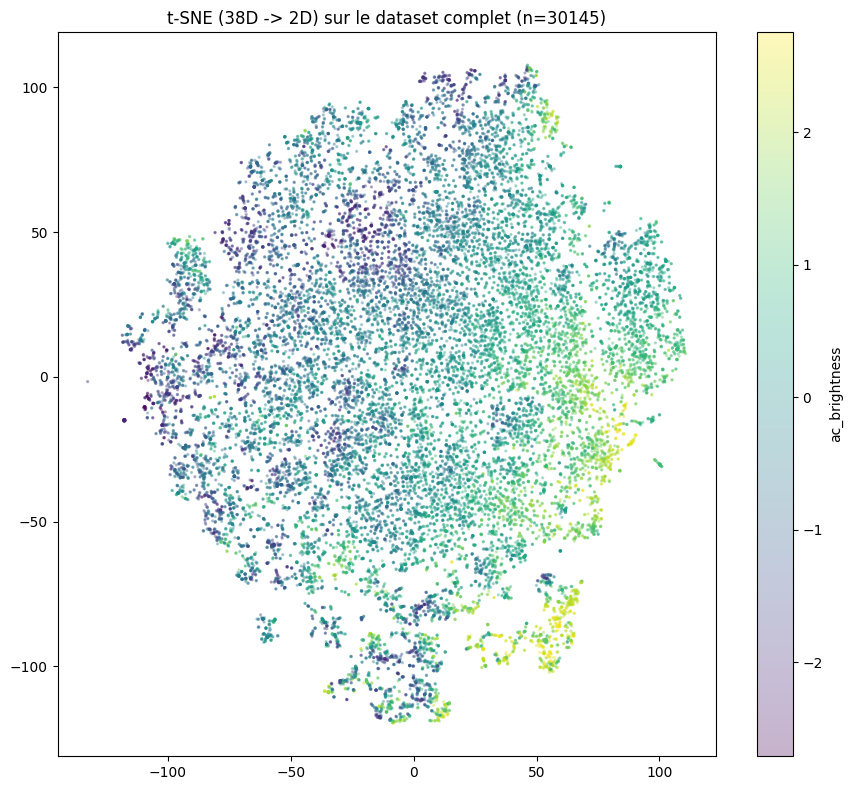

In [28]:
import time
from sklearn.manifold import TSNE

t0 = time.time()
tsne_full = TSNE(n_components=2, perplexity=30, random_state=0, n_jobs=-1)
X38_tsne_full = tsne_full.fit_transform(X38)
print(f"t-SNE (30k) termine en {time.time()-t0:.1f}s")

fig, ax = plt.subplots(figsize=(9,8))
sc = ax.scatter(X38_tsne_full[:,0], X38_tsne_full[:,1], c=behaviour_df['ac_brightness'], s=2, cmap='viridis', alpha=0.3)
plt.colorbar(sc, label='ac_brightness')
ax.set_title(f't-SNE (38D -> 2D) sur le dataset complet (n={len(X38_tsne_full)})')
plt.tight_layout(); plt.show()

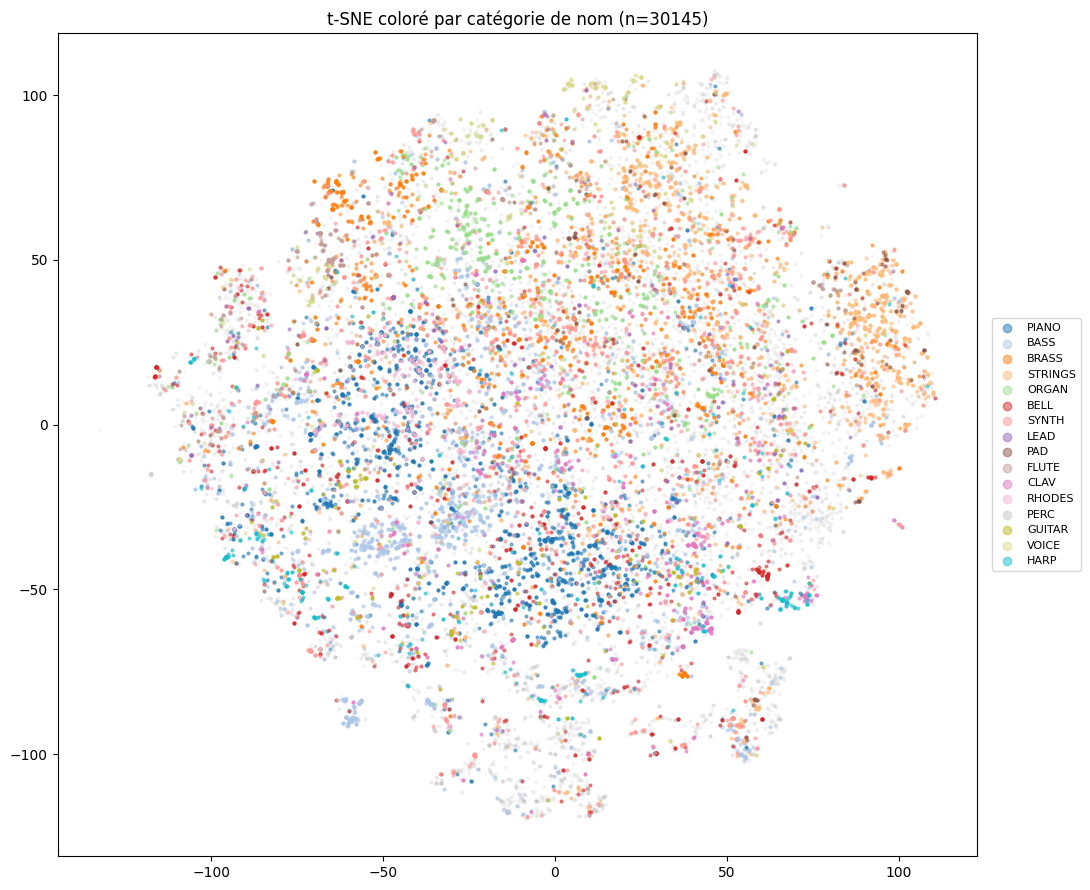

In [29]:
fig, ax = plt.subplots(figsize=(11,9))
palette = plt.cm.tab20(np.linspace(0, 1, len(categories)+1))
cat_array = cat_labels.reindex(behaviour_df.index).values

mask_other = cat_array == 'OTHER'
ax.scatter(X38_tsne_full[mask_other,0], X38_tsne_full[mask_other,1], s=3, alpha=0.1, color='lightgray', zorder=1)

for i, cat in enumerate(categories.keys()):
    mask = cat_array == cat
    ax.scatter(X38_tsne_full[mask,0], X38_tsne_full[mask,1], s=4, alpha=0.5, color=palette[i], label=cat, zorder=2)

ax.legend(markerscale=3, loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=8)
ax.set_title(f't-SNE coloré par catégorie de nom (n={len(behaviour_df)})')
plt.tight_layout(); plt.show()

### Summary of results so far

- The canonical 38-feature behaviour space (6 ACTM + 32 TT, exactly matching the SpinVAE2 paper's
  selection) was successfully reproduced from the regenerated Dexed dataset.
- PCA on this space explains ~44% of variance on 2 components -- the space is genuinely
  multi-dimensional, no single pair of axes summarises it well.
- The UMAP projection shows a broadly connected structure, but with visibly denser and sparser
  sub-regions, and at least one small, distinctly separated cluster of bright/high-`ac_brightness`
  presets, isolated from the main body of points.
- Colouring by a purely spectral TT feature (`tt_SpecCent_IQR`) shows a similar (though not
  identical) organisation to the semantic ACTM feature, suggesting the map's structure is not an
  artefact of one specific descriptor.
- Grid occupancy and nearest-neighbour distance give a first quantitative coverage baseline,
  computed on 500 presets so far -- to be recomputed on the full 30k-preset dataset once the
  ongoing TT+ACTM computation on `bonsho` finishes.

## 6. Select and export sounds to download

Pick UIDs of interest (e.g. sparse regions of the canonical map) and copy their wav files, then from your
local machine: `scp 'bonsho:~/to_download/*.wav' ~/dexed_listen/`

In [17]:
import shutil
DL_DIR = os.path.expanduser('~/to_download')
os.makedirs(DL_DIR, exist_ok=True)

def export_for_download(uids, variation=0):
    copied = []
    for uid in uids:
        src = wav_path(uid, variation)
        if os.path.exists(src):²
            name = db.get_preset_name(uid).replace('/', '_').replace(' ', '_')
            dst = os.path.join(DL_DIR, f"{uid:06d}_{name}.wav")
            shutil.copy(src, dst)
            copied.append(dst)
    print(f"Copied {len(copied)} files to {DL_DIR}")
    return copied

example_uids = list(behaviour_df.sample(min(10, len(behaviour_df)), random_state=1).index)
export_for_download(example_uids)

SyntaxError: invalid character '²' (U+00B2) (3967276689.py, line 9)

### Next steps
- Once the full-dataset (30k presets) TT+ACTM computation finishes on `bonsho`, reload `raw_timbre_features.df.pickle`
  here and re-run sections 4-5 on the complete behaviour space.
- Quantify coverage (convex hull area, grid-cell occupancy, nearest-neighbour distances) as the baseline
  to compare against IMGEP-guided exploration.
- Compare this canonical 38-feature map against the earlier librosa-only map (section 3) to check whether
  the same dense/sparse regions appear in both.